In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

In [5]:
from google.colab import files
uploaded=files.upload()

Saving Mall_Customers[1].csv to Mall_Customers[1].csv


In [8]:
df=pd.read_csv("Mall_Customers[1].csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [9]:
print(df.shape)

(200, 5)


In [10]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [11]:
print(df.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [12]:
X=df[["Annual Income (k$)","Spending Score (1-100)"]]

In [13]:
print(X.shape)

(200, 2)


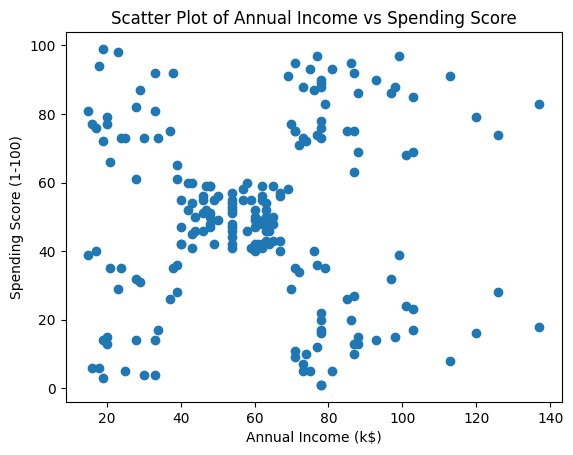

In [16]:
plt.scatter(X["Annual Income (k$)"],X["Spending Score (1-100)"])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Scatter Plot of Annual Income vs Spending Score")
plt.show()

In [18]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [19]:
print(X_scaled)

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]
 [-1.39547433 -0.59008772]
 [-1.39547433  0.88513158]
 [-1.3573049  -1.75473454]
 [-1.3573049   0.88513158]
 [-1.24279661 -1.4053405 ]
 [-1.24279661  1.23452563]
 [-1.24279661 -0.7065524 ]
 [-1.24279661  0.41927286]
 [-1.20462718 -0.74537397]
 [-1.20462718  1.42863343]
 [-1.16645776 -1.7935561 ]
 [-1.16645776  0.88513158]
 [-1.05194947 -1.7935561 ]
 [-1.05194947  1.62274124]
 [-1.05194947 -1.4053405 ]
 [-1.05194947  1.19570407]
 [-1.01378004 -1.28887582]
 

In [33]:
dbscan=DBSCAN(eps=0.5,min_samples=5)

In [34]:
clusters=dbscan.fit_predict(X_scaled)

In [35]:
print(clusters)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1
  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0  1  0 -1
 -1  1 -1 -1 -1 -1 -1 -1]


In [37]:
df["clusters"]=clusters
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,-1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [40]:
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

print("Number of clusters:", n_clusters)

Number of clusters: 2


In [43]:
n_noise = list(clusters).count(-1)
noise_percentage = (n_noise / len(clusters)) * 100

print("Noise Percentage:", noise_percentage)

Noise Percentage: 4.0


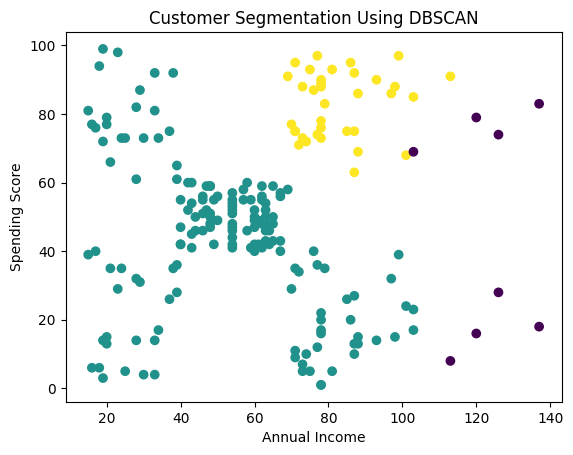

In [44]:
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=clusters
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation Using DBSCAN")

plt.show()

In [45]:
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(
    X_scaled
)

In [47]:
import numpy as np
distances = np.sort(
    distances[:, 4]
)

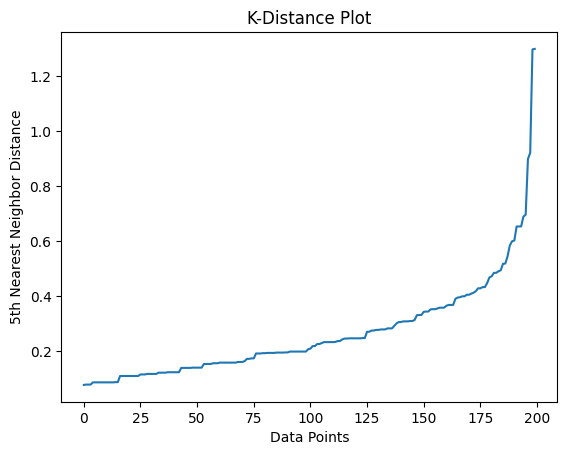

In [48]:
plt.plot(distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot")

plt.show()

In [49]:
eps_values = [
    0.2,
    0.3,
    0.4,
    0.5,
    0.6
]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    n_noise = list(labels).count(-1)

    print(
        f"eps={eps}, "
        f"clusters={n_clusters}, "
        f"noise={n_noise}"
    )

eps=0.2, clusters=7, noise=77
eps=0.3, clusters=7, noise=35
eps=0.4, clusters=4, noise=15
eps=0.5, clusters=2, noise=8
eps=0.6, clusters=1, noise=5


In [50]:
min_samples_values = [3, 4, 5, 6, 8, 10]

for samples in min_samples_values:

    model = DBSCAN(
        eps=0.4,
        min_samples=samples
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    n_noise = list(labels).count(-1)

    print(
        f"min_samples={samples}, "
        f"clusters={n_clusters}, "
        f"noise={n_noise}"
    )

min_samples=3, clusters=4, noise=10
min_samples=4, clusters=3, noise=14
min_samples=5, clusters=4, noise=15
min_samples=6, clusters=4, noise=19
min_samples=8, clusters=5, noise=25
min_samples=10, clusters=4, noise=51


In [51]:
mask = clusters != -1

clean_X = X_scaled[mask]
clean_clusters = clusters[mask]

In [52]:
if len(set(clean_clusters)) >= 2:

    score = silhouette_score(
        clean_X,
        clean_clusters
    )

    print("Silhouette Score:", score)

Silhouette Score: 0.3875583892728279


In [55]:
outliers = df[
    df["clusters"] == -1
]

print(outliers)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
191         192  Female   32                 103                      69   
192         193    Male   33                 113                       8   
194         195  Female   47                 120                      16   
195         196  Female   35                 120                      79   
196         197  Female   45                 126                      28   
197         198    Male   32                 126                      74   
198         199    Male   32                 137                      18   
199         200    Male   30                 137                      83   

     clusters  
191        -1  
192        -1  
194        -1  
195        -1  
196        -1  
197        -1  
198        -1  
199        -1  


In [56]:
print("Total Outliers:", len(outliers))


Total Outliers: 8
